# Real-data outlook: recovering cell-type programs in PBMCs with sparse ZQE

A small feasibility sketch (not a paper result): point the overcomplete sparse ZQE discovery at
**real single-cell counts** and ask whether the discovered local factors line up with *known*
biology — canonical PBMC cell-type marker programs (T / B / NK / monocyte / DC / platelet).

Data: 10x **pbmc3k** (2700 PBMCs, raw UMI counts — Poisson-native).
Preprocessing (standard scRNA, removes technical confounds — not result-tuning): drop
mito/ribosomal/immediate-early genes, **depth-normalize by downsampling to a common per-cell
total** (keeps integer counts; removes the library-size confound so composition drives the
factors). Then top ~2000 HVGs → `SparseZQEFitter` overcomplete (q=30, L1) → for each discovered
factor, hypergeometric enrichment of its gene support against marker sets."

In [1]:
import numpy as np, torch, scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
sc.settings.verbosity = 0
device = "cuda" if torch.cuda.is_available() else "cpu"

adata = sc.datasets.pbmc3k()              # raw UMI counts
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# --- standard scRNA cleanup: drop technical / generic programs that otherwise dominate ---
# mito (MT-), ribosomal (RPS/RPL/MRPS/MRPL), and dissociation immediate-early/heat-shock genes.
keep = ~adata.var_names.str.match(r"^(MT-|RP[SL]|MRP[SL])")
IEG = {"JUN","JUNB","JUND","FOS","FOSB","EGR1","DUSP1","IER2","ZFP36","ATF3",
       "HSPA1A","HSPA1B","HSPB1","NR4A1","DNAJB1"}
keep &= ~adata.var_names.str.upper().isin(IEG)
adata = adata[:, keep].copy()

# --- depth normalization for Poisson: downsample every cell to a COMMON total (keeps integer
# counts, unlike normalize_total). Removes the library-size confound so composition — not depth —
# drives the factors (and the majority T-cell program isn't absorbed into a dense depth factor). ---
tot = np.asarray(adata.X.sum(1)).ravel()
floor = int(np.percentile(tot, 15))
adata = adata[tot >= floor].copy()
sc.pp.downsample_counts(adata, counts_per_cell=floor, random_state=0)

# HVG by dispersion on the cleaned counts (manual: avoids the scikit-misc dependency)
Xd = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
mean = Xd.mean(0); var = Xd.var(0)
disp = np.divide(var, mean, out=np.zeros_like(mean), where=mean > 0)
pool = np.where(mean > 0.0125)[0]
hvg = pool[np.argsort(disp[pool])[::-1][:2000]]
adata = adata[:, np.sort(hvg)].copy()

genes = [s.upper() for s in adata.var_names]
Y = torch.tensor(adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X),
                 dtype=torch.float32)
print(f"after cleanup: {tuple(Y.shape)} (cells x genes)   common depth ~{floor} UMIs/cell   "
      f"mean count {Y.mean():.2f}   sparsity {(Y == 0).float().mean():.0%}")

after cleanup: (2296, 2000) (cells x genes)   common depth ~873 UMIs/cell   mean count 0.30   sparsity 87%


## Discover programs — overcomplete sparse ZQE

In [2]:
from gllvm.gllvm_module import GLLVM
from gllvm.glms import PoissonGLM
from gllvm.autofit_sparse import SparseZQEFitter
from gllvm.encoder import MapEncoderPoissonNewton

Q = 30          # overcomplete: more factors than expected programs
P = Y.shape[1]
L1, L2 = 0.05, 0.01

torch.manual_seed(0)
g = GLLVM(latent_dim=Q, output_dim=P)
g.add_glm(PoissonGLM, idx=range(P), params={"T": torch.log1p})
torch.nn.init.normal_(g.wz, std=0.5); torch.nn.init.zeros_(g.bias)
g = g.to(device)

ft = SparseZQEFitter(
    g, encoder_factory=lambda g: MapEncoderPoissonNewton(g, lam=1.0, max_iter=30),
    l1=L1, l2=L2, steps=400, refine_lr=0.2, revive_jitter=0.0,
    device=device, seed=0, verbose=True,
).fit(Y.to(device))

W = ft.model.wz.detach().cpu().numpy()
mask = ft.mask_.cpu().numpy().astype(bool)
live = mask.sum(0) > 0
print(f"\nlive factors: {live.sum()}/{Q}   nonzeros/live factor: "
      f"{mask.sum(0)[live].mean():.0f}  (of {P} genes)")

[warm-up] adam lr=0.1 (exit at lr≤0.002)


  ep  100  loss=+80.1174  gnorm=6.6182  lr=5.00e-02


  ep  200  loss=+38.0021  gnorm=5.1011  lr=5.00e-02


  ep  300  loss=+19.9849  gnorm=4.0343  lr=2.50e-02


  ep  400  loss=+12.9521  gnorm=3.3911  lr=1.25e-02


...

  step  240/400  loss=+38.1633  λ1=0.05  lr=0.013  live=29/30  supp-zeros=99%  (iter-zeros=81%)


  step  280/400  loss=+40.0823  λ1=0.05  lr=0.012  live=29/30  supp-zeros=99%  (iter-zeros=84%)


  step  320/400  loss=+41.9541  λ1=0.05  lr=0.011  live=29/30  supp-zeros=99%  (iter-zeros=85%)


  step  360/400  loss=+42.4278  λ1=0.05  lr=0.011  live=30/30  supp-zeros=99%  (iter-zeros=87%)


  step  400/400  loss=+39.6538  λ1=0.05  lr=0.010  live=29/30  supp-zeros=99%  (iter-zeros=88%)
[done]  live factors 29/30  mask zeros 99%  (→ freeze mask, refit with ZQEAutoFitter for the precise fit)

live factors: 29/30   nonzeros/live factor: 25  (of 2000 genes)


## Do the discovered factors match known cell-type programs?

Hypergeometric enrichment of each factor's gene support against canonical PBMC markers.

In [3]:
from scipy.stats import hypergeom

MARKERS = {
    "T cell":        ["CD3D","CD3E","CD3G","TRAC","IL7R","LCK","CD2","CD7"],
    "CD8/cytotoxic": ["CD8A","CD8B","GZMK","GZMA","CCL5","NKG7","GZMH"],
    "NK":            ["GNLY","NKG7","KLRD1","KLRB1","KLRF1","NCAM1","PRF1","FGFBP2"],
    "B cell":        ["MS4A1","CD79A","CD79B","CD19","IGHM","IGHD","TCL1A"],
    "CD14 mono":     ["CD14","LYZ","S100A8","S100A9","S100A12","FCN1","VCAN"],
    "FCGR3A mono":   ["FCGR3A","MS4A7","CDKN1C","LST1","AIF1","COTL1"],
    "DC":            ["FCER1A","CST3","CLEC10A","HLA-DQA1"],
    "platelet":      ["PPBP","PF4","GP9","ITGA2B","NRGN","GNG11"],
}
gidx = {s: i for i, s in enumerate(genes)}
Mtot = len(genes)

# enrichment matrix: -log10 p  (factor x program)
names = list(MARKERS)
present = {n: [gidx[x] for x in gl if x in gidx] for n, gl in MARKERS.items()}
E = np.zeros((int(live.sum()), len(names)))
live_ids = np.where(live)[0]
for r, k in enumerate(live_ids):
    supp = set(np.where(mask[:, k])[0]); ns = len(supp)
    for c, n in enumerate(names):
        pres = present[n]; ov = len(supp & set(pres))
        p = hypergeom.sf(ov - 1, Mtot, len(pres), ns) if ov > 0 and pres else 1.0
        E[r, c] = -np.log10(max(p, 1e-300))

# best program per factor
print("factor -> best-matching program (enrichment)")
hits = 0
for r, k in enumerate(live_ids):
    c = int(E[r].argmax()); nlp = E[r, c]
    if nlp > 3:  # p < 1e-3
        ns = int(mask[:, k].sum())
        top = [genes[i] for i in np.argsort(-np.abs(W[:, k]))[:6] if mask[i, k]]
        print(f"  factor {k:2d}  [{ns:3d} genes]  -> {names[c]:13s} "
              f"(-log10p={nlp:4.1f})   top: {', '.join(top)}")
        hits += 1
programs_found = sorted({names[int(E[r].argmax())] for r in range(len(live_ids)) if E[r].max() > 3})
print(f"\n{hits} factors enriched (p<1e-3); programs recovered: {programs_found}")

factor -> best-matching program (enrichment)
  factor  1  [ 10 genes]  -> FCGR3A mono   (-log10p= 3.7)   top: GZMK, TMSB10, CST3, LST1, FCER1G, LGALS1
  factor  3  [ 12 genes]  -> CD8/cytotoxic (-log10p= 5.2)   top: CCL3, CD8B, FTH1, CCL5, S100A11, SAT1
  factor  6  [ 13 genes]  -> CD8/cytotoxic (-log10p= 5.1)   top: CD8B, FTL, S100A9, CD74, S100A8, CST3
  factor  8  [ 18 genes]  -> FCGR3A mono   (-log10p= 5.2)   top: AIF1, IFITM3, LST1, TYROBP, FCER1G, FCGR3A
  factor 10  [ 16 genes]  -> FCGR3A mono   (-log10p= 5.4)   top: GNLY, GZMB, CCL4, COTL1, AIF1, CST3
  factor 12  [  5 genes]  -> CD8/cytotoxic (-log10p= 4.0)   top: GZMK, CCL5, LTB, LDHB, ACTG1
  factor 13  [ 65 genes]  -> B cell        (-log10p= 6.0)   top: CD79A, TCL1A, VPREB3, MS4A1, LINC00926, HLA-DQA1
  factor 14  [ 50 genes]  -> NK            (-log10p= 5.3)   top: GZMB, GNLY, NKG7, FGFBP2, CLIC3, PRF1
  factor 15  [ 14 genes]  -> CD8/cytotoxic (-log10p= 3.0)   top: VIM, FCGR3A, NKG7, GAPDH, TMSB10, CCL5
  factor 18  [ 76 g

## Enrichment map — which factor is which program

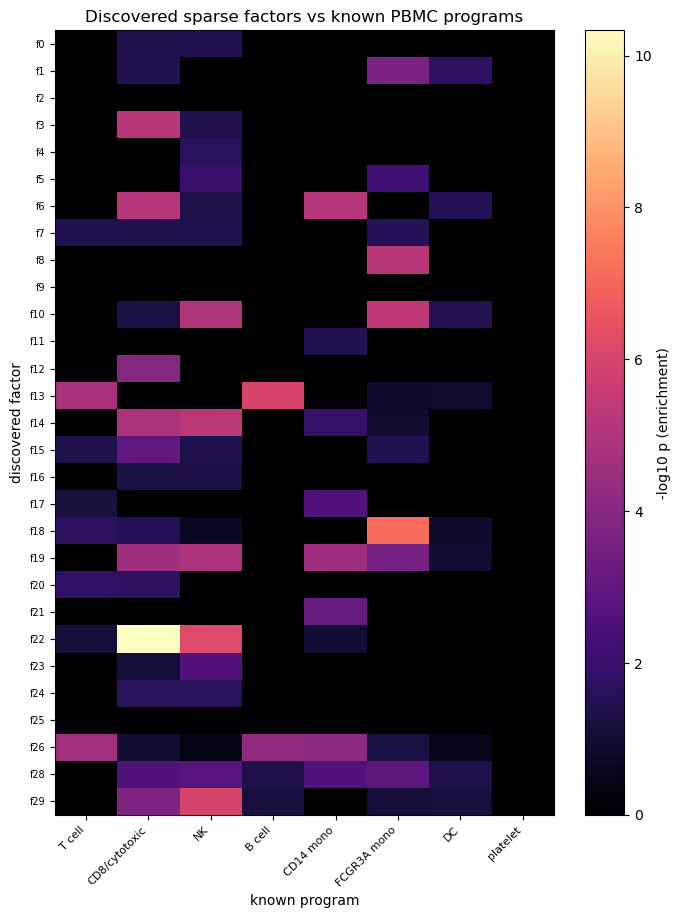

In [4]:
fig, ax = plt.subplots(figsize=(7, max(4, 0.32 * len(live_ids))))
im = ax.imshow(np.clip(E, 0, 30), aspect="auto", cmap="magma")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(live_ids))); ax.set_yticklabels([f"f{k}" for k in live_ids], fontsize=7)
ax.set_xlabel("known program"); ax.set_ylabel("discovered factor")
fig.colorbar(im, ax=ax, label="-log10 p (enrichment)")
ax.set_title("Discovered sparse factors vs known PBMC programs")
plt.tight_layout(); plt.show()